In [3]:
%load_ext autoreload 
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import nibabel as nib
import os
%matplotlib inline 
sub = 'sub-03'



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
dm_file = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/logfiles/TestSubj_TestSess_Run1_colour_Cond.mat'
tdm_mat = sio.loadmat(dm_file)
tn_trs = 90 # 90 timepts
t_tr = 3 #

In [284]:
log_dir = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/logfiles'
dm_files_ = os.listdir(log_dir)
dm_files = [i for i in dm_files_ if '.mat' in i]
dm_files

['TestSubj_TestSess_Run1_colour.mat',
 'col_dm_cond.mat',
 'col_dm.mat',
 'TestSubj_TestSess_Run1_colour_Cond.mat']

In [4]:

dm_conds = [str(i[0]) for i in tdm_mat['names'][0]]
ons = {}
dur = {}
cond_list = []
for iC,c in enumerate(dm_conds):
    ons[c] = tdm_mat['onsets'][0][iC][0] # weird matlab... have to index this way
    print(ons[c])
    ons[c] = [int(i / t_tr) for i in ons[c]]
    print(ons[c])
    # durations 
    # HMM. ARRGH 
    dur[c] = tdm_mat['durations'][0][iC][0] #int(tdm_mat['durations'][0][iC][0] // t_tr) # in trs
    if c != 'rest':
        cond_list.append(c)
dmatrix = np.zeros((tn_trs, len(cond_list)))
for iC,c in enumerate(cond_list):
    for tonset in ons[c]:
        # toffset = tonset+dur[c]
        # dmatrix[tonset:toffset,iC] = 1.0
        dmatrix[tonset,iC] = 1.0
dur = 30 # HMMM

t_dmatrix_info = {
    'dur' : dur, 
    'cond_list' : cond_list, 
    'ons' : ons,
    'dmatrix' : dmatrix, 
}

[8.45125000e-04 2.55008815e+02]
[0, 85]
[ 45.00162958  75.01012975 165.00254796 195.00816542]
[15, 25, 55, 65]
[ 15.01033804 105.00170842 135.01069308 225.01644929]
[5, 35, 45, 75]


In [9]:
import os
opj = os.path.join
moco_folder = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/spm_align/sub-03'
rfiles_ = os.listdir(
    moco_folder
)
rfiles = [opj(moco_folder,f) for f in rfiles_ if f.startswith('rsub')]
rfiles = rfiles[1::] # remove run1 for some reason...
rnib = [nib.load(f) for f in rfiles]
rdata = []
for i in range(len(rnib)):
    rdata.append(rnib[i].get_fdata())
# run1_file = 
# r1 = nib.load(run1_file)
# tfunc = r1.get_fdata()

In [150]:
# plt.imshow(tfunc[:,:,-20,0])
# tfsl = tfunc[:,:,-21:-20,:].copy()

In [11]:
import glmsingle
from glmsingle.glmsingle import GLM_single
import scipy
import os
import shutil
opj = os.path.join
# create a directory for saving GLMsingle outputs
deriv_dir = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives'
outputdir_glmsingle = opj(deriv_dir, 'glmsingle', sub, 'glmsingle001')
if not os.path.exists(outputdir_glmsingle):
    os.makedirs(outputdir_glmsingle)
else:
    shutil.rmtree(outputdir_glmsingle)
    os.makedirs(outputdir_glmsingle)

opt = dict()

# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 1
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 0

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [1,1,1,1]
opt['wantmemoryoutputs'] = [1,1,1,1]

# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
glmsingle_obj = GLM_single(opt)

# visualize all the hyperparameter

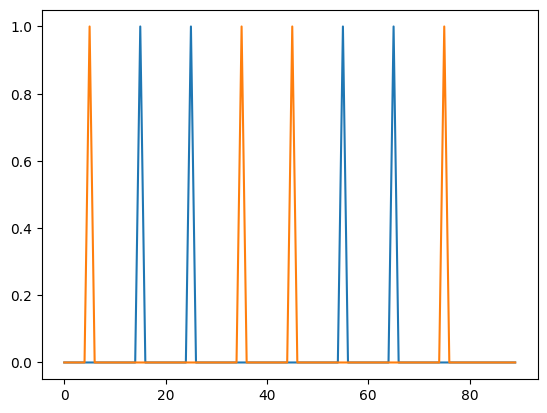

In [12]:
plt.plot(t_dmatrix_info['dmatrix'])
dm1id = np.array([0,3,4,7])
dm2id = np.array([1,2,5,6])

In [13]:
# variables that will contain bold time-series and design matrices from each run
data = []
design = []

nruns = 0
for R in range(len(rdata)):
    data.append(
        rdata[R],
        # tfunc #[:,:,20:21,:]
        )
    design.append(t_dmatrix_info['dmatrix'])
    nruns += 1

# get shape of data volume (XYZ) for convenience
xyz = data[0].shape[:3]
xyzt = data[0].shape

# get total number of blocks - this will be the dimensionality of output betas from GLMsingle
nblocks = int(np.sum(np.concatenate(design)))

# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0

In [15]:
# run GLMsingle
results_glmsingle = glmsingle_obj.fit(
   design,
   data,
   stimdur,
   tr,
   outputdir=outputdir_glmsingle)

*** DIAGNOSTICS ***:
There are 9 runs.
The number of conditions in this experiment is 2.
The stimulus duration corresponding to each trial is 30.00 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [8, 8, 8, 8, 8, 8, 8, 8, 8].
The number of trials for each condition is: [np.int64(36), np.int64(36)].
For each condition, the number of runs in which it appears: [np.int64(9), np.int64(9)].
For each run, how much ending buffer do we have in seconds? [np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0)].
*** Saving design-related results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-03/glmsingle001/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-03/glm

chunks: 100%|██████████| 24/24 [05:55<00:00, 14.80s/it]



*** Saving results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-03/glmsingle001/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 24/24 [06:35<00:00, 16.49s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 24/24 [02:57<00:00,  7.40s/it]



*** Saving results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-03/glmsingle001/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** All model types done ***

*** return model types in results ***



In [ ]:
# Get m
# meanvol = np.squeeze(np.mean(data[0].reshape(xyzt),3))
r2_th = results_glmsingle['typeb']['R2'] #>20
# brainmask = meanvol > 2500
beta_id = {
    'bw' : [0,3,4,7],
    'col':[1,2,5,6],
}
betas = {}
for k in beta_id.keys():
    betas[k] = []
    for i in beta_id[k]:
        betas[k].append(results_glmsingle['typec']['betasmd'][:,:,:,i])
    betas[k] = np.mean(betas[k], axis=0)

# bth = betas.copy()
# for k in bth.keys():
    
#     bth[k][~brainmask] = np.nan
#     bth[k][~r2_th] = np.nan


In [39]:
results_glmsingle['typec']['betasmd'].shape

(164, 164, 50, 72)

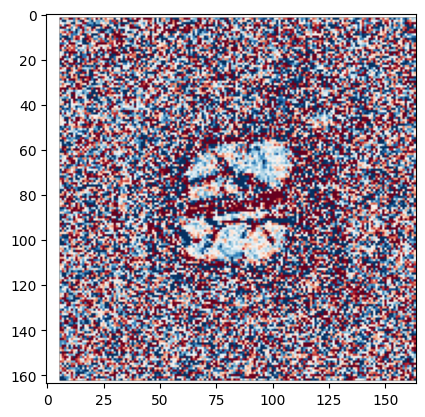

In [42]:
plt.imshow(
    # betas['bw'][:,:,-10],
    np.nanmean(results_glmsingle['typec']['betasmd'][:,:,-10,:], axis=-1),
    vmin=-5, vmax=5, cmap='RdBu',
    # vmin=0, vmax=1,
           )

14.486885


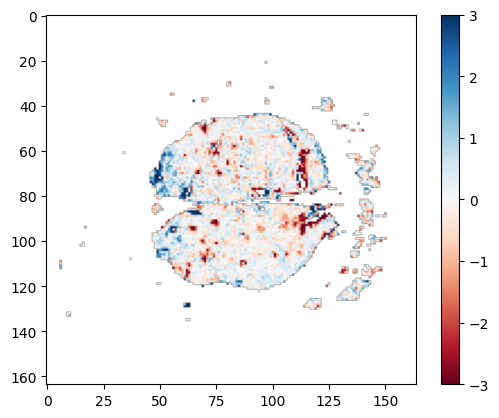

In [78]:
isl = -15
tdata = betas['bw'][:,:,isl] #np.nanmean(results_glmsingle['typec']['betasmd'][:,:,-10, :], axis=-1)
tdata =  betas['col'][:,:,isl] -  betas['bw'][:,:,isl] 
tmask = results_glmsingle['typec']['meanvol'][:,:,isl]>5000
tdata[~tmask] = np.nan
print(np.nanmax(tdata))
#results_glmsingle['typec']['meanvol'][:,:,-10]>3200,
plt.imshow(
    # betas['bw'][:,:,-10],
    tdata,
    vmin=-3, vmax=3, cmap='RdBu',
    # vmin=0, vmax=1,
           )
plt.colorbar()

In [53]:
# Reference your data
data = results_glmsingle['typec']['betasmd']

# Calculate how many chunks of 8 there are
# data.shape[-1] gives the size of the last dimension
num_chunks = data.shape[-1] // 8

# Split along the last dimension (axis=-1)
chunks = np.split(data, num_chunks, axis=-1)


# Next - average over corresponding trials
beta_id = {
    'bw' : [0,3,4,7],
    'col':[1,2,5,6],
}
betas = {}

for k in beta_id.keys():
    betas[k] = []
    for chunk in chunks: 
        for i in beta_id[k]:
            betas[k].append(chunk[:,:,:,i])
    print(len(betas[k]))
    betas[k] = np.mean(betas[k], axis=0)

36
36


In [80]:
tdata = betas['col'] -  betas['bw']
tmask = results_glmsingle['typec']['meanvol']>5000
tdata[~tmask] = np.nan
ball_img = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)
nib.save(ball_img, 'glmsings03.nii')

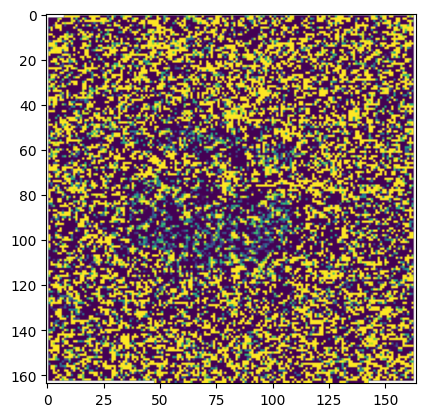

In [367]:
plt.imshow(betas['col'][:,:,-10]-betas['bw'][:,:,-20],vmin=0, vmax=5)

In [322]:
ball=(bth['col']+bth['bw'])/2
ball=results_glmsingle['typea']['onoffR2']
ball

array([[[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan, 1.00662245e-01, 2.17699017e-01, ...,
                    nan,            nan,            nan],
        [           nan, 2.01462661e-01, 1.15008030e-01, ...,
                    nan,            nan,            nan],
        [           nan, 

In [361]:
np.nanmax(results_glmsingle['typeb']['R2'])

np.float32(76.29336)

In [368]:
# ball = results_glmsingle['typeb']['R2']
ball_img = betas['col'] - betas['bw']
ball_img = nib.Nifti1Image(ball.astype(np.float32), rnib[0].affine)
nib.save(ball_img, 'glmSingColmBw.nii')


In [376]:
# np.nanmin(betas['col'])
np.nanmin(betas['col']-betas['bw'])

np.float32(-106.83902)

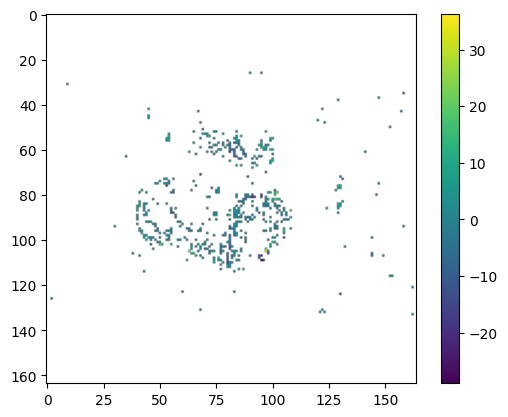

In [252]:
sl = -8
plt.imshow(bth['bw'][:,:,sl]-bth['col'][:,:,sl],
        #    vmin=0, vmax=3, 
        
           )
plt.colorbar()

In [253]:
results_glmsingle['typeb']['betasmd'].shape

(164, 164, 50, 24)

In [ ]:
rnib[0].header['pixdim']



import nibabel as nib


# Load the NIfTI file
img = nib.load('your_file.nii')

# Get the header
header = img.header

# Set TR to 3 seconds (stored in milliseconds typically, but check your format)
header['pixdim'][4] = 3.0

# Save with corrected header
nib.save(img, 'corrected_file.nii')

array([-1.        ,  0.902439  ,  0.902439  ,  0.90000004,  0.        ,
        0.        ,  0.        ,  0.        ], dtype=float32)

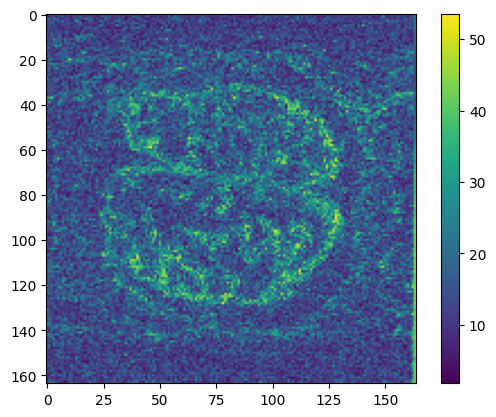

In [97]:
plt.imshow(results_glmsingle['typeb']['R2'].squeeze()[:,:,-20])
plt.colorbar()

dict_keys(['FitHRFR2', 'FitHRFR2run', 'HRFindex', 'HRFindexrun', 'R2', 'R2run', 'betasmd', 'meanvol'])


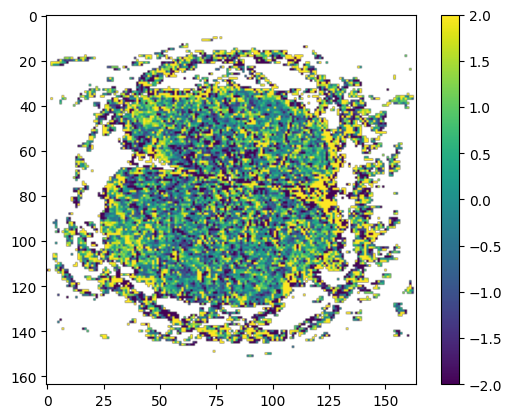

In [100]:
print(results_glmsingle['typeb'].keys())
plot_data = results_glmsingle['typeb']['betasmd'].mean(axis=-1).squeeze()
plot_data.shape
meanvol = np.squeeze(np.mean(data[0].reshape(xyzt),3))
brainmask = meanvol > 2500

# plt.imshow()
plot_data[~brainmask] = np.nan # remove values outside the brain for visualization purposes

plt.imshow(plot_data[:,:,-20], vmin=-2, vmax=2)
plt.colorbar()

In [81]:
meanvol.mean()

np.float32(7107.5527)

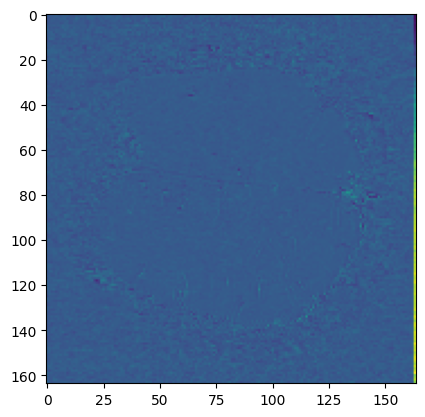

In [73]:
plt.imshow(results_glmsingle['typeb']['betasmd'][:,:,:,-2])

KeyError: 'typec'

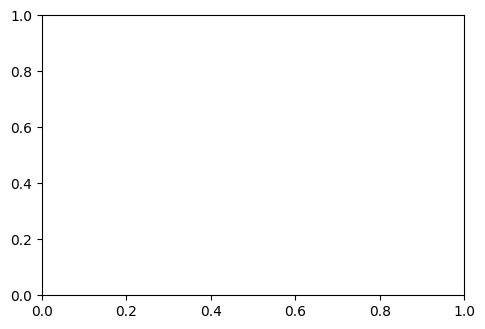

In [43]:
# we are going to plot several outputs from the FIT_HRF_GLMdenoise_RR GLM,
# which contains the full set of GLMsingle optimizations.

# we will plot betas, R2, optimal HRF indices, and the voxel frac values
plot_fields = ['betasmd','R2','HRFindex','FRACvalue']
colormaps = ['RdBu_r','hot','jet','copper']
clims = [[-5,5],[0,85],[0,20],[0,1]]

meanvol = np.squeeze(np.mean(data[0].reshape(xyzt),3))
brainmask = meanvol > 275

plt.figure(figsize=(12,8))

for i in range(len(plot_fields)):
    
    plt.subplot(2,2,i+1)
    
    if i == 0:
        # when plotting betas, for simplicity just average across all image presentations
        # this will yield a summary of whether voxels tend to increase or decrease their 
        # activity in response to the experimental stimuli (similar to outputs from 
        # an ONOFF GLM)
        plot_data = np.nanmean(np.squeeze(results_glmsingle['typec'][plot_fields[i]]),3).astype(float)
        titlestr = 'average GLM betas (localizer runs 1-4)'
    
    else:
        # plot all other voxel-wise metrics as outputted from GLMsingle
        plot_data = np.squeeze(results_glmsingle['typed'][plot_fields[i]].reshape(xyz)).astype(float)
        titlestr = plot_fields[i]
    
    plot_data[~brainmask] = np.nan # remove values outside the brain for visualization purposes
    plt.imshow(plot_data[:,5:-5,20],cmap=colormaps[i],clim=clims[i])
    plt.colorbar()
    plt.title(titlestr)
    plt.axis(False)

AxisError: axis 3 is out of bounds for array of dimension 3

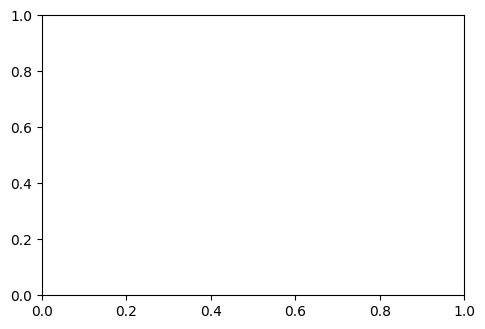

In [73]:
# we will plot betas, R2, optimal HRF indices, and the voxel frac values
plot_fields = ['betasmd','R2','HRFindex','FRACvalue']
colormaps = ['RdBu_r','hot','jet','copper']
clims = [[-5,5],[0,85],[0,20],[0,1]]

meanvol = np.squeeze(np.mean(data[0].reshape(xyzt),3))
brainmask = meanvol > 275

plt.figure(figsize=(12,8))

for i in range(len(plot_fields)):
    
    plt.subplot(2,2,i+1)
    
    if i == 0:
        # when plotting betas, for simplicity just average across all image presentations
        # this will yield a summary of whether voxels tend to increase or decrease their 
        # activity in response to the experimental stimuli (similar to outputs from 
        # an ONOFF GLM)
        plot_data = np.nanmean(np.squeeze(results_glmsingle['typec'][plot_fields[i]]),3).astype(float)
        titlestr = 'average GLM betas (localizer runs 1-4)'
    
    else:
        # plot all other voxel-wise metrics as outputted from GLMsingle
        plot_data = np.squeeze(results_glmsingle['typec'][plot_fields[i]].reshape(xyz)).astype(float)
        titlestr = plot_fields[i]
    
    plot_data[~brainmask] = np.nan # remove values outside the brain for visualization purposes
    plt.imshow(plot_data[:,5:-5,20],cmap=colormaps[i],clim=clims[i])
    plt.colorbar()
    plt.title(titlestr)
    plt.axis(False)

In [69]:
results_glmsingle['typec'].keys()

dict_keys(['HRFindex', 'HRFindexrun', 'glmbadness', 'pcvoxels', 'pcnum', 'xvaltrend', 'noisepool', 'pcregressors', 'betasmd', 'R2', 'R2run', 'meanvol'])